## Appendix - A

In [22]:
# import initial libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# load data
location= 'diabetes.csv'

df = pd.read_csv(location)

In [24]:
# define target and features
target = df['Diabetes_012']
features = df.drop(['Diabetes_012'], axis=1)

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [26]:
# find VIF for each feature to check for multilinearity
vif_data = pd.DataFrame()
vif_data['feature'] = features.columns
vif_data['VIF'] = [variance_inflation_factor(features.values, i) for i in range(len(features.columns))]

In [27]:
print(vif_data)

                 feature        VIF
0                 HighBP   2.299761
1               HighChol   2.029660
2              CholCheck  23.187436
3                    BMI  18.149913
4                 Smoker   1.933042
5                 Stroke   1.126777
6   HeartDiseaseorAttack   1.289820
7           PhysActivity   4.645314
8                 Fruits   3.032775
9                Veggies   5.826886
10     HvyAlcoholConsump   1.083523
11         AnyHealthcare  20.839710
12           NoDocbcCost   1.215834
13               GenHlth  10.740162
14              MentHlth   1.463103
15              PhysHlth   1.999556
16              DiffWalk   1.838551
17                   Sex   1.910708
18                   Age   9.886830
19             Education  29.507416
20                Income  14.156118


In [28]:
features2 = features.drop(['CholCheck', 'AnyHealthcare', 'Education'], axis=1)

## Appendix - B

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
# split 80/20 testing and training sets
features_train, features_test, target_train, target_test = train_test_split(features2, target, test_size=0.2, random_state=0)

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV

In [32]:
# set the min ma x scaler 
minmax_scale = preprocessing.MinMaxScaler(feature_range=(0,1))
# knn classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
# pipeline
pipe = Pipeline([('min-max', minmax_scale), ('knn', knn)])

In [33]:
# create seach space for number of nearest neighbors
search_space = [{"knn__n_neighbors": [2, 3, 4, 5, 6, 7]}]

In [34]:
# create a model with the best value for n neighbors
classifier = GridSearchCV(pipe, search_space, cv=5, verbose=0).fit(features_train, target_train)

In [35]:
print("Best value for n_neighbors:",classifier.best_estimator_.get_params()["knn__n_neighbors"])

Best value for n_neighbors: 6


In [36]:
# predicted values for new model
pred_best = classifier.predict(features_test)

In [37]:
from sklearn.metrics import accuracy_score

In [38]:
# calculate accuracy for KNN model
knn_acc = accuracy_score(target_test, pred_best)
print("Accuracy: {0:.3f} ".format(knn_acc))

Accuracy: 0.834 


## Appendix - C

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [40]:
# create pipeline with min-max scaler
pipe2 = Pipeline([('min-max', minmax_scale), ('classifier', RandomForestClassifier())])

In [41]:
# create pipeline with min-max scaler
pipe3 = Pipeline([('min-max', minmax_scale), ('classifier', RandomForestClassifier())])

In [42]:
search_space2 = [{'classifier': [LogisticRegression(max_iter=500,
                                                    solver='liblinear')],
                                 'classifier__penalty':['l1', 'l2'],
                                 'classifier__C': np.logspace(0, 4, 10)},
                 {'classifier': [RandomForestClassifier()], 
                  'classifier__n_estimators': [10, 100, 1000],
                  'classifier__max_features': [1, 2, 3]},
                {'classifier':[KNeighborsClassifier(n_neighbors=6, n_jobs=-1)]}]

In [43]:
searchspace3 = search_space2 = [
                 {'classifier': [RandomForestClassifier()], 
                  'classifier__n_estimators': [10, 100, 1000],
                  'classifier__max_features': [1, 2, 3]}]

In [44]:
classifier3 = GridSearchCV(pipe3, searchspace3, cv=5, verbose=0)

In [45]:
# fit model
best_model2 = classifier3.fit(features_train, target_train)

In [46]:
pred_best3 = best_model2.predict(features_test)
acc3 = accuracy_score(target_test, pred_best3)
print("Accuracy: {0:.3f} ".format(acc3))

Accuracy: 0.840 


In [47]:
# create the new classifier
classifier2 = GridSearchCV(pipe2, search_space2, cv=5, verbose=0)

In [48]:
# fit model
best_model = classifier2.fit(features_train, target_train)

In [49]:
# results for best model
print(best_model.best_estimator_)

Pipeline(steps=[('min-max', MinMaxScaler()),
                ('classifier',
                 RandomForestClassifier(max_features=3, n_estimators=1000))])


In [50]:
# predictions from model
pred_best2 = best_model.predict(features_test)

In [51]:
# accuracy of best selected model
acc2 = accuracy_score(target_test, pred_best2)
print("Accuracy: {0:.3f} ".format(acc2))

Accuracy: 0.840 


In [52]:
log_model = LogisticRegression(max_iter=500, penalty='l1', solver='liblinear')

In [53]:
log_model.fit(features_train, target_train)

LogisticRegression(max_iter=500, penalty='l1', solver='liblinear')

In [54]:
best_pred = log_model.predict(features_test)

In [55]:
acc_best = accuracy_score(target_test, best_pred)
print("Accuracy: {0:.3f} ".format(acc_best))

Accuracy: 0.846 


## Appendix - D

In [56]:
# get coefficients for log model
coefficients = log_model.coef_[0]

<Axes: ylabel='Feature'>

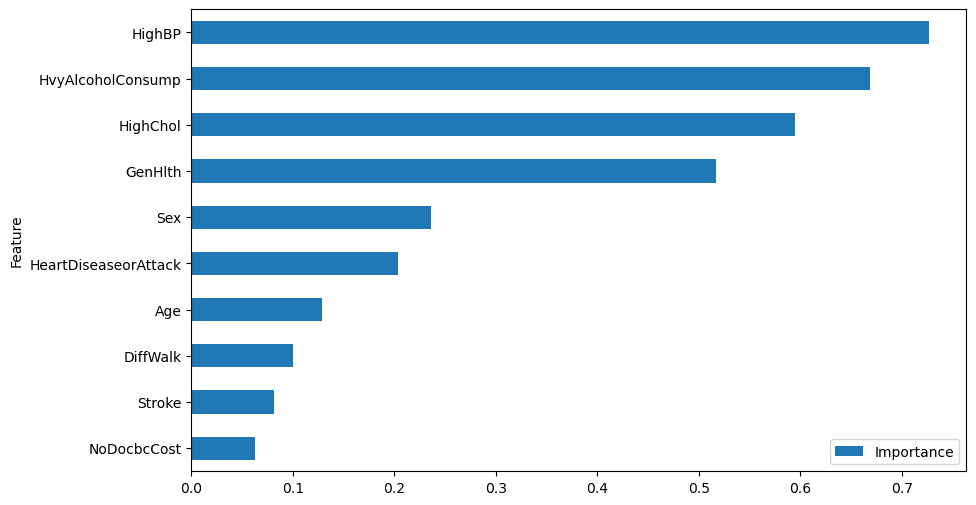

In [57]:
# plot top ten coefficients for Log Model
feature_importance = pd.DataFrame({'Feature': features_train.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
top10_features = feature_importance.sort_values('Importance', ascending=False)[:10]
top10_features.sort_values('Importance', ascending=True).plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))

In [81]:
high_bp = df[['Diabetes_012', 'HighBP']]
high_bp.columns = ['Diabetes','High Blood Pressure']

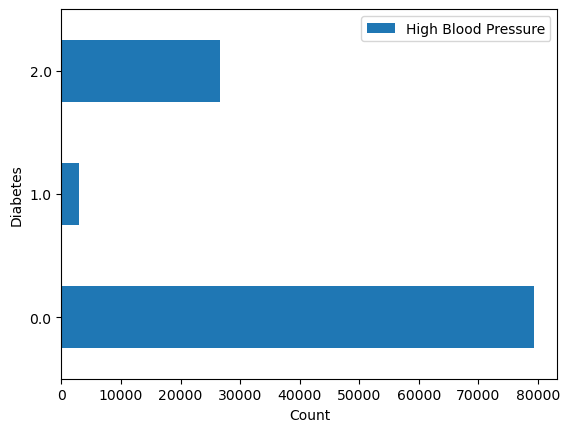

In [82]:
high_bp.groupby('Diabetes').sum().plot.barh()
plt.xlabel('Count')
plt.ylabel('Diabetes')
plt.show()

In [77]:
alc = df[['Diabetes_012', 'HvyAlcoholConsump']]
alc.columns = ['Diabetes', 'Heavy Alcohol Consumption']

<Axes: ylabel='Diabetes'>

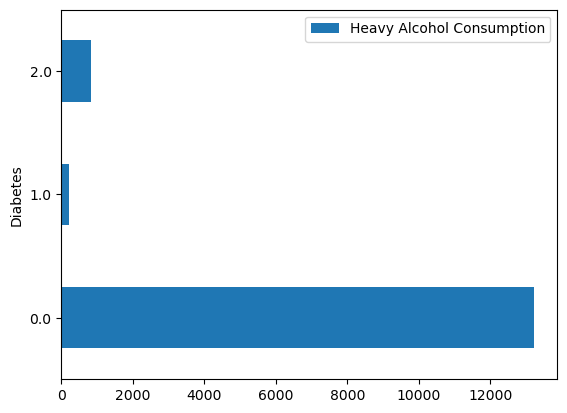

In [79]:
alc.groupby('Diabetes').sum().plot.barh()

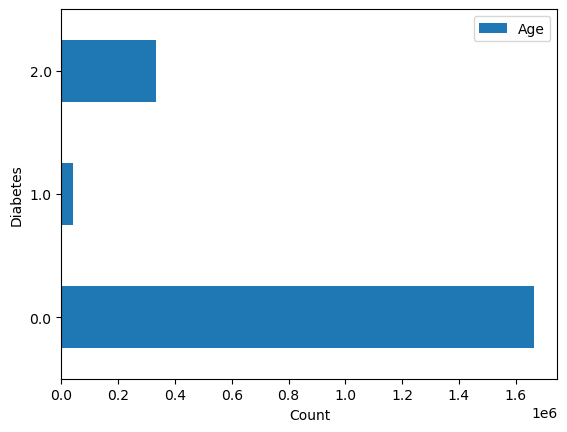

In [73]:
age = df[['Diabetes_012', 'Age']]
age.groupby('Diabetes_012').sum().plot.barh()
plt.xlabel('Count')
plt.ylabel('Diabetes')
plt.show()

/var/folders/02/7bqyfhrj065fjkf5y69x1pv40000gn/T/ipykernel_32608/1736737664.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sex['Sex'] = sex['Sex'].replace({0:'Female', 1:'Male'})


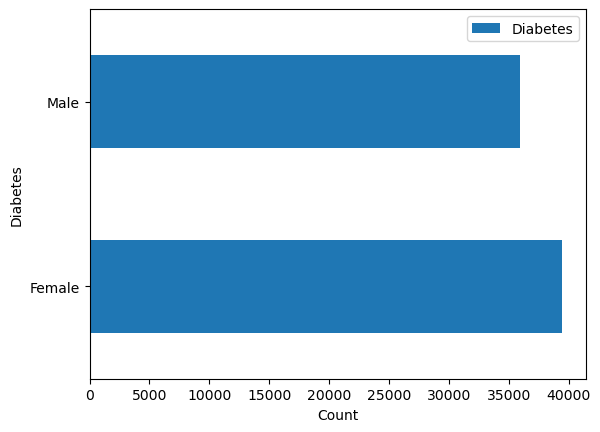

In [83]:
sex = df[['Diabetes_012', 'Sex']]
sex.columns = ['Diabetes', 'Sex']
sex['Sex'] = sex['Sex'].replace({0:'Female', 1:'Male'})
sex.groupby('Sex').sum().plot.barh()
plt.xlabel('Count')
plt.ylabel('Diabetes')
plt.show()

In [68]:
features3 = features2.drop(['Sex', 'Age'], axis=1)

In [67]:
features_train2, features_test2, target_train2, target_test2 = train_test_split(features3, target, test_size=0.2, random_state=0)

In [70]:
log_model.fit(features_train2, target_train2)

LogisticRegression(max_iter=500, penalty='l1', solver='liblinear')

In [71]:
best_pred3 = log_model.predict(features_test2)
acc_best = accuracy_score(target_test2, best_pred3)
print("Accuracy: {0:.3f} ".format(acc_best))

Accuracy: 0.846 
